# Advanced Mutual Fund Analytics

This notebook calculates historical daily VaR/CVaR, 90-observation rolling Sharpe, investor cohorts, SIP continuity, and portfolio concentration from the supplied project datasets. Shared calculations live in `analytics/advanced_analytics.py` so the notebook and command-line recommender use the same definitions.

**Return-data choice:** risk statistics use original observed NAV records from `data/raw/02_nav_history.csv`. The cleaned NAV file forward-fills holidays and weekends; those synthetic flat observations would add zero returns and understate volatility and tail risk. The observed raw NAV source contains all 40 schemes through May 29, 2026.

In [4]:
from pathlib import Path
import sys
from IPython.display import Image, display

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "analytics" / "advanced_analytics.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the project analytics/advanced_analytics.py module from the notebook working directory.")
sys.path.insert(0, str(PROJECT_ROOT))

from analytics.advanced_analytics import run_all, recommend_funds

results = run_all()
print(f"Observed NAV return rows: {len(results['returns']):,}")
print(f"Schemes in VaR/CVaR report: {results['var_cvar']['amfi_code'].nunique()}")
print("Wrote reports/var_cvar_report.csv and reports/rolling_sharpe_chart.png")

Observed NAV return rows: 45,960
Schemes in VaR/CVaR report: 40
Wrote reports/var_cvar_report.csv and reports/rolling_sharpe_chart.png


## 1. Historical VaR and CVaR

VaR is the empirical 5th percentile of observed daily returns (95% confidence), reported as a return percentage; negative numbers indicate losses. CVaR is the mean of returns at or below that quantile. All 40 schemes use the same observed-NAV date range and report their sample counts.

In [5]:
var_table = results['var_cvar'].sort_values('var_95_daily_return_pct')
display(var_table.head(10).style.format({'var_95_daily_return_pct': '{:.3f}%', 'cvar_95_daily_return_pct': '{:.3f}%'}))

,amfi_code,scheme_name,risk_grade,var_confidence_pct,var_95_daily_return_pct,cvar_95_daily_return_pct,observations,tail_observations,start_date,end_date
22,119599,SBI Small Cap Fund - Direct Plan - Growth,Very High,95.000000,-2.686%,-3.238%,1149,58,2022-01-04,2026-05-29
17,119095,Axis Small Cap Fund - Regular - Growth,Very High,95.000000,-2.619%,-3.167%,1149,58,2022-01-04,2026-05-29
4,101207,ABSL Small Cap Fund - Regular - Growth,Very High,95.000000,-2.602%,-3.246%,1149,58,2022-01-04,2026-05-29
11,118634,Nippon India Small Cap Fund - Regular - Growth,Very High,95.000000,-2.544%,-3.230%,1149,58,2022-01-04,2026-05-29
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Very High,95.000000,-2.451%,-3.060%,1149,58,2022-01-04,2026-05-29
39,149324,DSP Small Cap Fund - Regular - Growth,Very High,95.000000,-2.348%,-3.104%,1149,58,2022-01-04,2026-05-29
7,102886,UTI Mid Cap Fund - Regular - Growth,High,95.000000,-1.922%,-2.325%,1149,58,2022-01-04,2026-05-29
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Growth,High,95.000000,-1.903%,-2.346%,1149,58,2022-01-04,2026-05-29
25,120505,ICICI Pru Midcap Fund - Regular - Growth,High,95.000000,-1.889%,-2.434%,1149,58,2022-01-04,2026-05-29
16,119094,Axis Midcap Fund - Regular - Growth,High,95.000000,-1.848%,-2.426%,1149,58,2022-01-04,2026-05-29


### Insight 1 — Tail-risk leaders

SBI Small Cap Fund – Direct Plan – Growth has the most negative observed 95% daily VaR in this sample, at approximately **−2.69%**; its lower-tail CVaR is approximately **−3.24%** per day. This is a historical sample estimate, not a forecast or maximum possible loss.

## 2. Rolling 90-observation Sharpe

For the five requested large-cap schemes, the plotted measure is the 90-observation rolling mean daily return divided by rolling sample standard deviation, multiplied by √252. As specified, this rolling measure does not subtract a risk-free rate.

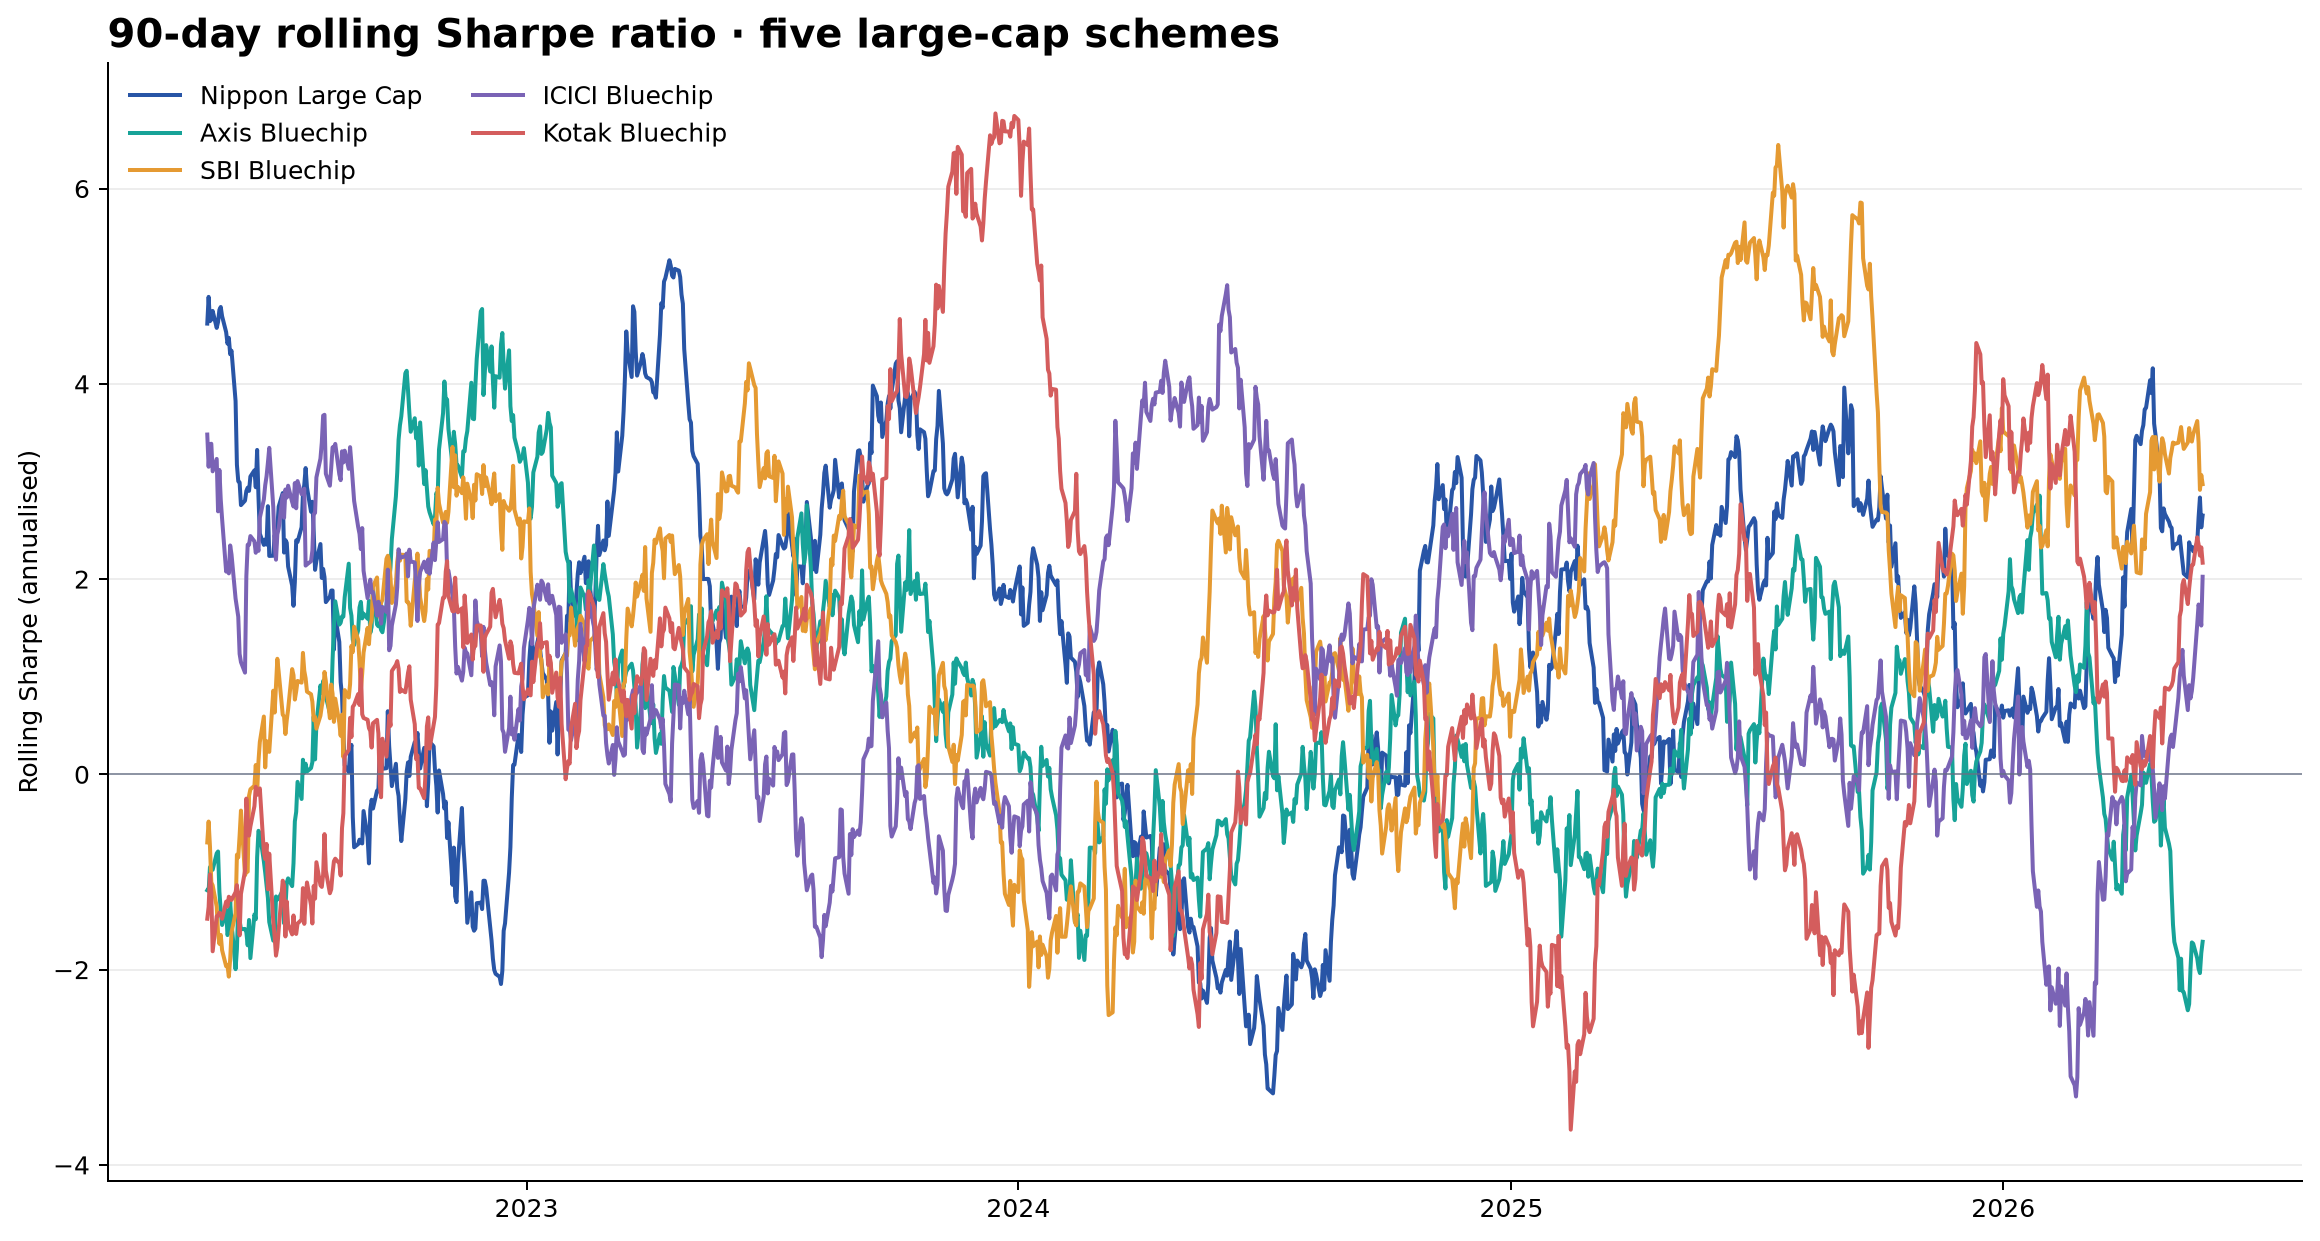

In [6]:
display(Image(filename='../reports/rolling_sharpe_chart.png', width=1000))

### Insight 2 — Rolling risk-adjusted performance

Each of the five selected schemes has **1,060 valid 90-observation windows** in the observed NAV history, beginning after the initial 90 return observations. Compare the rolling lines over time rather than treating a single full-period Sharpe ranking as stable.

## 3. Investor cohorts

Cohort year is the calendar year of an investor's first transaction in the supplied transaction sample. Average SIP amount is the mean SIP transaction ticket in that cohort; total invested sums SIP and Lumpsum transactions and excludes Redemptions. Top fund preference is the most frequently transacted scheme by SIP transaction count.

In [7]:
display(results['cohorts'].style.format({'avg_sip_amount_inr': '₹{:,.0f}', 'total_invested_inr': '₹{:,.0f}'}))

,cohort_year,investor_count,avg_sip_amount_inr,total_invested_inr,investment_transactions,top_sip_fund,amfi_code,sip_transaction_count
0,2024,4803,"₹10,997","₹2,258,062,304",27578,ICICI Pru Bluechip Fund - Direct - Growth,120504,536
1,2025,197,"₹13,505","₹18,992,635",233,SBI Small Cap Fund - Direct Plan - Growth,119599,8


### Insight 3 — Cohort investment contribution

The 2024 first-transaction cohort contains **4,803 investors** and invested approximately **₹225.81 crore** through SIP and Lumpsum transactions in the available sample. Its most frequent SIP scheme is ICICI Pru Bluechip Fund – Direct – Growth (**536 SIP transactions**). The 2025 cohort is partial-year coverage, so cohort totals are not directly comparable without accounting for exposure time.

## 4. SIP continuity

The eligible population is investors with at least six distinct SIP transaction dates. Average inter-SIP gap is calculated in calendar days; an investor is flagged **At-risk** when their average gap exceeds 35 days. Continuity rate is the proportion of eligible investors not flagged At-risk.

In [8]:
display(results['sip_continuity_summary'].style.format({'continuity_rate_pct': '{:.2f}%'}))
display(results['sip_continuity'].head(10))

,eligible_investors_6plus_sips,at_risk_investors_avg_gap_over_35d,continuing_investors,continuity_rate_pct,at_risk_rule
0,1362,1332,30,2.20%,mean interval between consecutive SIP transactions > 35 days


,investor_id,sip_transaction_count,first_sip_date,last_sip_date,avg_gap_days,max_gap_days,continuity_status
506,INV001890,6,2024-01-02,2025-05-29,102.6,207.0,At-risk
323,INV001156,6,2024-01-02,2025-05-28,102.4,175.0,At-risk
1188,INV004296,6,2024-01-02,2025-05-27,102.2,304.0,At-risk
910,INV003325,6,2024-01-07,2025-05-26,101.0,155.0,At-risk
150,INV000522,6,2024-01-12,2025-05-30,100.8,309.0,At-risk
183,INV000608,6,2024-01-09,2025-05-24,100.2,324.0,At-risk
503,INV001883,6,2024-01-16,2025-05-26,99.2,203.0,At-risk
576,INV002166,6,2024-01-01,2025-05-11,99.2,248.0,At-risk
380,INV001367,6,2024-01-03,2025-05-12,99.0,222.0,At-risk
406,INV001491,6,2024-01-07,2025-05-15,98.8,260.0,At-risk


### Insight 4 — SIP continuity needs attention

Of **1,348 eligible investors** with six or more SIP dates, **27 (2.00%)** have an average interval of 35 days or less; the remaining **1,321** are flagged At-risk by this rule. The low continuity rate is specific to this transaction sample and the average-gap rule; it is not a verified SIP cancellation measure.

## 5. Risk-appetite recommender

The recommender ranks schemes by annualized Sharpe calculated from observed daily NAV returns, using a 6.5% annual risk-free-rate proxy (the repo-rate assumption used in the project's prior performance analysis). Low maps to Low risk grade, Moderate maps to Moderate, and High includes Moderately High, High, and Very High grades. These are descriptive historical rankings, not personalized financial advice.

In [9]:
for appetite in ['Low', 'Moderate', 'High']:
    print(f'\n{appetite} risk appetite')
    display(recommend_funds(appetite, results['sharpe'])[['scheme_name', 'risk_grade', 'sharpe_ratio_daily']].style.format({'sharpe_ratio_daily': '{:.3f}'}))


Low risk appetite


,scheme_name,risk_grade,sharpe_ratio_daily
0,ICICI Pru Liquid Fund - Regular - Growth,Low,0.496
1,Kotak Liquid Fund - Regular - Growth,Low,-0.089
2,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,-0.227



Moderate risk appetite


,scheme_name,risk_grade,sharpe_ratio_daily
0,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.448
1,SBI Bluechip Fund - Regular Plan - Growth,Moderate,1.208
2,Nippon India Large Cap Fund - Regular - Growth,Moderate,1.082



High risk appetite


,scheme_name,risk_grade,sharpe_ratio_daily
0,Kotak Flexicap Fund - Regular - Growth,Moderately High,1.307
1,Mirae Asset Tax Saver Fund - Regular - Growth,High,1.235
2,ICICI Pru Midcap Fund - Regular - Growth,High,1.180


### Insight 5 — Risk-appetite ranking is grade-sensitive

In the Moderate group, Mirae Asset Large Cap Fund – Regular – Growth ranks first by observed-NAV Sharpe (**1.448**), followed by SBI Bluechip Regular (**1.208**) and Nippon India Large Cap Regular (**1.082**). The result uses a 6.5% annual risk-free proxy and historical NAV coverage through May 2026; it should not be interpreted as a forward return promise.

## 6. Equity portfolio concentration

Stock-weight HHI is Σ(weight_pct²), on the conventional 0–10,000 scale. The supplied holdings snapshot covers 34 of the 34 equity schemes in the fund master. `disclosed_weight_pct` is retained as a coverage check; HHI is calculated from reported holding weights without rescaling them.

In [10]:
display(results['sector_hhi'].head(15).style.format({'hhi': '{:,.1f}', 'disclosed_weight_pct': '{:.2f}%'}))

,amfi_code,scheme_name,fund_house,category,hhi,sector_count,holdings_count,disclosed_weight_pct,coverage_status
0,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity,"2,967.7",7,10,99.99%,Holdings available
1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,"2,549.9",7,9,99.98%,Holdings available
2,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Equity,"2,531.6",6,8,100.00%,Holdings available
3,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,"2,513.8",6,10,100.01%,Holdings available
4,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,"2,410.8",7,9,100.00%,Holdings available
5,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,"2,387.0",7,8,100.02%,Holdings available
6,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,Equity,"2,375.0",6,8,99.99%,Holdings available
7,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,"2,323.6",7,8,100.00%,Holdings available
8,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Equity,"2,314.6",7,9,100.02%,Holdings available
9,100033,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Mutual Fund,Equity,"2,276.5",7,9,100.00%,Holdings available


### Insight 6 — Portfolio concentration

Axis Bluechip Fund – Regular – Growth has the highest reported stock-weight HHI (**2,064.5**) among the supplied equity-fund holdings, based on 10 reported holdings totaling 99.99% of its portfolio snapshot. Holdings are a single supplied snapshot, so this concentration ranking may change over time.

## Reproducibility and caveats

Re-run `run_all()` to recompute the risk report and chart. The source transactions span January 2024–May 2025; investor-cohort and continuity findings are bounded by that sample. Portfolio holdings represent the supplied snapshot date only. VaR/CVaR, Sharpe ratios, HHI, and recommender output describe supplied historical data and are not investment advice.